In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [4]:
df=pd.read_csv("Mall_Customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(200, 5)


In [6]:
print("Dataset Information :")
print(df.info())

Dataset Information :
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


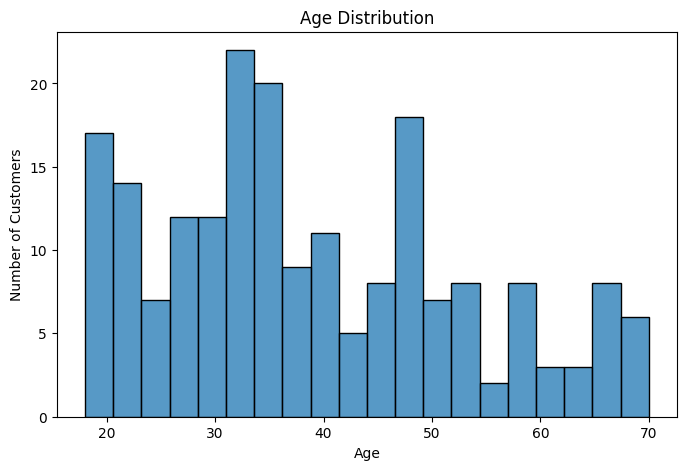

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

           

Gender Distribution 


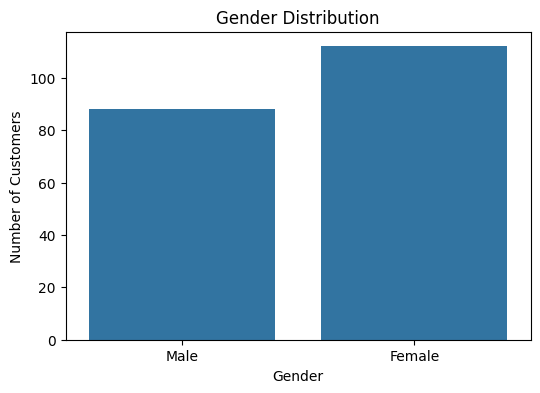

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender',data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

Annual Income VS Spending Score

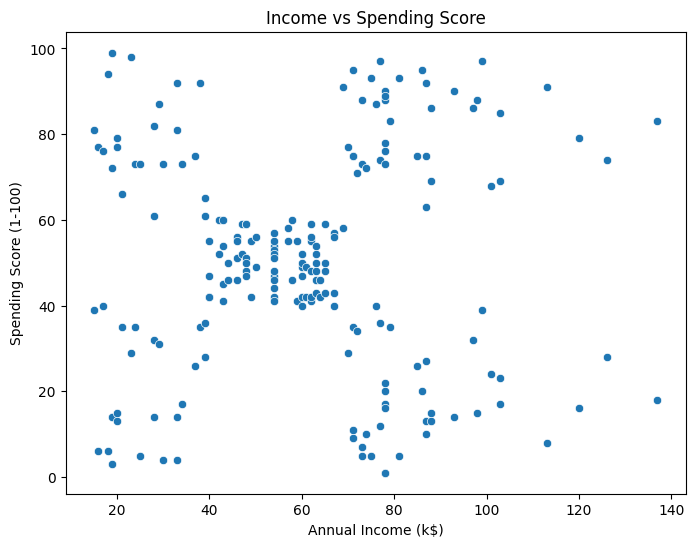

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [16]:
X=df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [17]:
# elbow method

wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

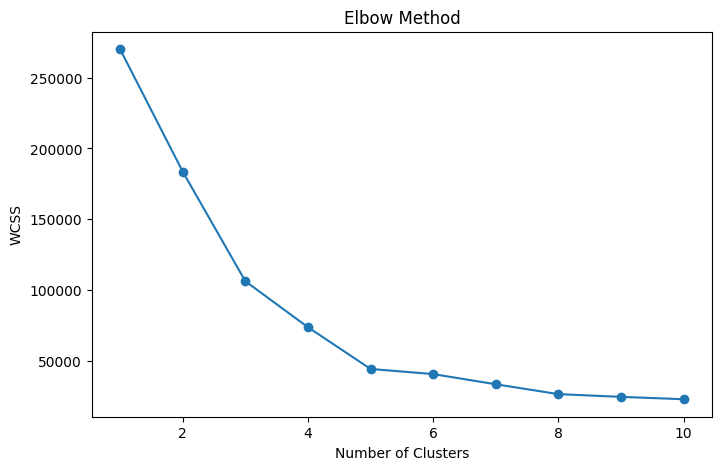

In [18]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

K-MEANS CLUSTERING

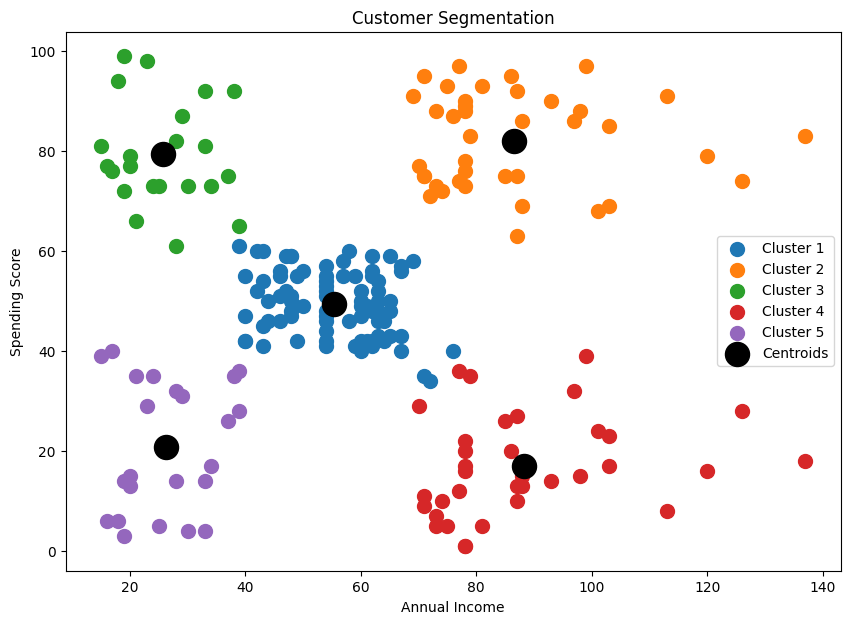

In [20]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(X)

plt.figure(figsize=(10,7))


# Cluster 1
plt.scatter(
    X.iloc[y_kmeans == 0, 0],
    X.iloc[y_kmeans == 0, 1],
    s=100,
    label='Cluster 1'
)

# Cluster 2
plt.scatter(
    X.iloc[y_kmeans == 1, 0],
    X.iloc[y_kmeans == 1, 1],
    s=100,
    label='Cluster 2'
)

# Cluster 3
plt.scatter(
    X.iloc[y_kmeans == 2, 0],
    X.iloc[y_kmeans == 2, 1],
    s=100,
    label='Cluster 3'
)

# Cluster 4
plt.scatter(
    X.iloc[y_kmeans == 3, 0],
    X.iloc[y_kmeans == 3, 1],
    s=100,
    label='Cluster 4'
)

# Cluster 5
plt.scatter(
    X.iloc[y_kmeans == 4, 0],
    X.iloc[y_kmeans == 4, 1],
    s=100,
    label='Cluster 5'
)

# Centroids

plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='black',label='Centroids')
plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()


C:\Users\gayat\AppData\Local\Temp\ipykernel_1564\17054710.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


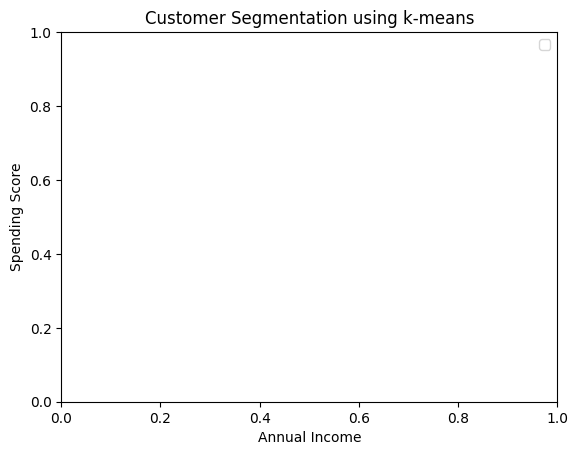

In [23]:
plt.title("Customer Segmentation using k-means")

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

In [24]:
# Add Clusters 

df['Cluster']=y_kmeans
print("UPDATED DATASET WITH CLUSTERS")

print(df.head())

df.to_csv("Clustered_Customers.csv",index=False)

print("Clustered_Customers.csv file saved successfully !!")

UPDATED DATASET WITH CLUSTERS
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
Clustered_Customers.csv file saved successfully !!


In [25]:
print("\nCLUSTER ANALYSIS\n")

print("Cluster 0 : Medium Income Medium Spending")
print("Cluster 1 : High Income High Spending")
print("Cluster 2 : Low Income High Spending")
print("Cluster 3 : High Income Low Spending")
print("Cluster 4 : Low Income Low Spending")


CLUSTER ANALYSIS

Cluster 0 : Medium Income Medium Spending
Cluster 1 : High Income High Spending
Cluster 2 : Low Income High Spending
Cluster 3 : High Income Low Spending
Cluster 4 : Low Income Low Spending


In [ ]:
# =========================================
# USER INPUT TESTING
# =========================================

# Use sample values instead of interactive input for notebook execution
income = 60.0
spending = 40.0

print("Sample input:")
print("Annual Income:", income)
print("Spending Score:", spending)

new_customer = [[income, spending]]

predicted_cluster = kmeans.predict(new_customer)

print("\nPredicted Cluster:", predicted_cluster[0])